# 4. Annotation and Labelling Framework

**Objective:** Design a transparent, reproducible labelling framework.

**Primary label:** `price_category` — affordable (<£300k), mid_range (£300k–£800k), luxury (>£800k).  
**Deliverables:** `data/processed/zoopla_labeled.csv`, `documentation/annotation_rules.md`.

## 4.1 Rationale for Price Category Thresholds

- **affordable (< £300,000):** First-time buyer / entry-level segment; aligns with UK help-to-buy and typical starter home ranges in many regions.
- **mid_range (£300,000 – £800,000):** Family homes and mid-market; covers a large share of UK transactions.
- **luxury (> £800,000):** Premium segment; London and high-value areas dominate.

*Subjectivity:* A £500k property may be mid-range nationally but expensive in smaller cities. Optional: add `price_category_by_city` using city-specific quantiles (see documentation).

In [1]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_PROCESSED = ROOT / "data" / "processed" / "zoopla_features.csv"
DATA_LABELED = ROOT / "data" / "processed" / "zoopla_labeled.csv"
(ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED)
# Ensure price is numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [2]:
# Primary label: price_category
def label_price(p):
    if pd.isna(p): return "unknown"
    if p < 300_000: return "affordable"
    if p <= 800_000: return "mid_range"
    return "luxury"

df["price_category"] = df["price"].apply(label_price)
print("Label distribution:")
print(df["price_category"].value_counts())

Label distribution:
price_category
affordable    8615
mid_range     4934
luxury         576
Name: count, dtype: int64


## 4.2 Quality Checks

Label distribution plot; mean price_per_sqft per label; random sample inspection.

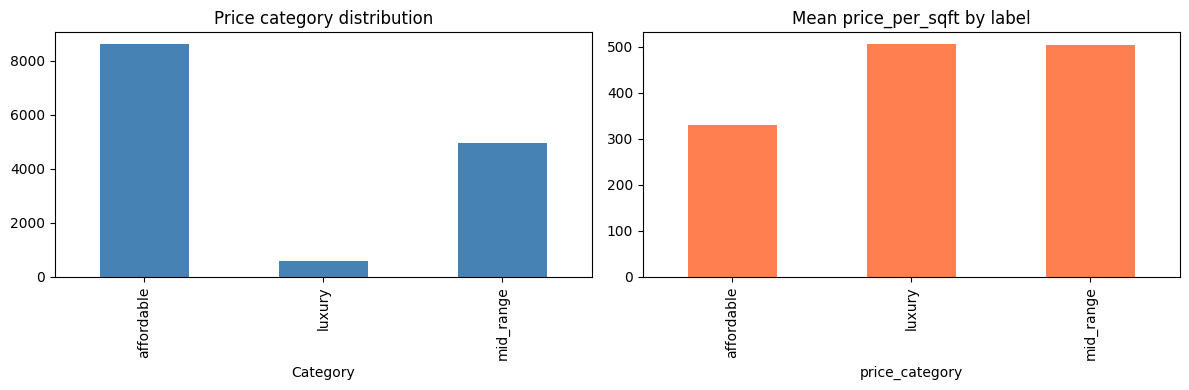


Random sample (price, price_category, city):
          price price_category            city
8094   420000.0      mid_range    Peterborough
6954   580000.0      mid_range  West Yorkshire
7387   335000.0      mid_range         Cardiff
10191  180000.0     affordable     Southampton
5084   350000.0      mid_range         Bristol


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["price_category"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Price category distribution")
axes[0].set_xlabel("Category")
if "price_per_sqft" in df.columns:
    df.groupby("price_category")["price_per_sqft"].mean().plot(kind="bar", ax=axes[1], color="coral")
    axes[1].set_title("Mean price_per_sqft by label")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
# Random sample
print("\nRandom sample (price, price_category, city):")
print(df[["price", "price_category", "city"]].dropna(subset=["price"]).sample(5))

In [4]:
df.to_csv(DATA_LABELED, index=False)
print("Saved labeled dataset:", DATA_LABELED)

Saved labeled dataset: /Users/hoamai/Personal/bradford/AI_AND_DATASCIENCE/final_v1/data/processed/zoopla_labeled.csv
